In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Simulation parameters (matching the raylib simulation exactly)
NEEDLE_LENGTH = 50      # Length of the needle in pixels
LINE_SPACING = 75       # Distance between the parallel lines in pixels
TOTAL_NEEDLES = 500_000
SIMULATION_WIDTH = 900

In [33]:
total_needles = 0
crossing_needles = 0
running_pi = []

for _ in range(TOTAL_NEEDLES):
    # Generate a random needle
    x = np.random.uniform(0, SIMULATION_WIDTH)
    y = np.random.uniform(0, SIMULATION_WIDTH)
    angle = np.random.uniform(0, np.pi)

    total_needles += 1

    # Check if the needle crosses a line
    distance_to_nearest_line = min(y % LINE_SPACING, LINE_SPACING - (y % LINE_SPACING))
    half_length_vertical = (NEEDLE_LENGTH / 2) * np.sin(angle)

    if half_length_vertical >= distance_to_nearest_line:
        crossing_needles += 1

    # Estimate pi
    if crossing_needles == 0:
        running_pi.append(np.nan)
    else:
        numerator = 2 * NEEDLE_LENGTH * total_needles
        denominator = LINE_SPACING * crossing_needles
        running_pi.append(numerator / denominator)

running_pi = np.array(running_pi)

error = np.abs(running_pi - np.pi)
error_percentage = (error / np.pi) * 100

print(f"Final estimate: {running_pi[-1]:.6f} ({TOTAL_NEEDLES} needles)")
print(f"Final error: {error[-1]}")
print(f"Final error percentage: {error_percentage[-1]:.4f}%")

Final estimate: 3.146851 (500000 needles)
Final error: 0.0052582926682864795
Final error percentage: 0.1674%


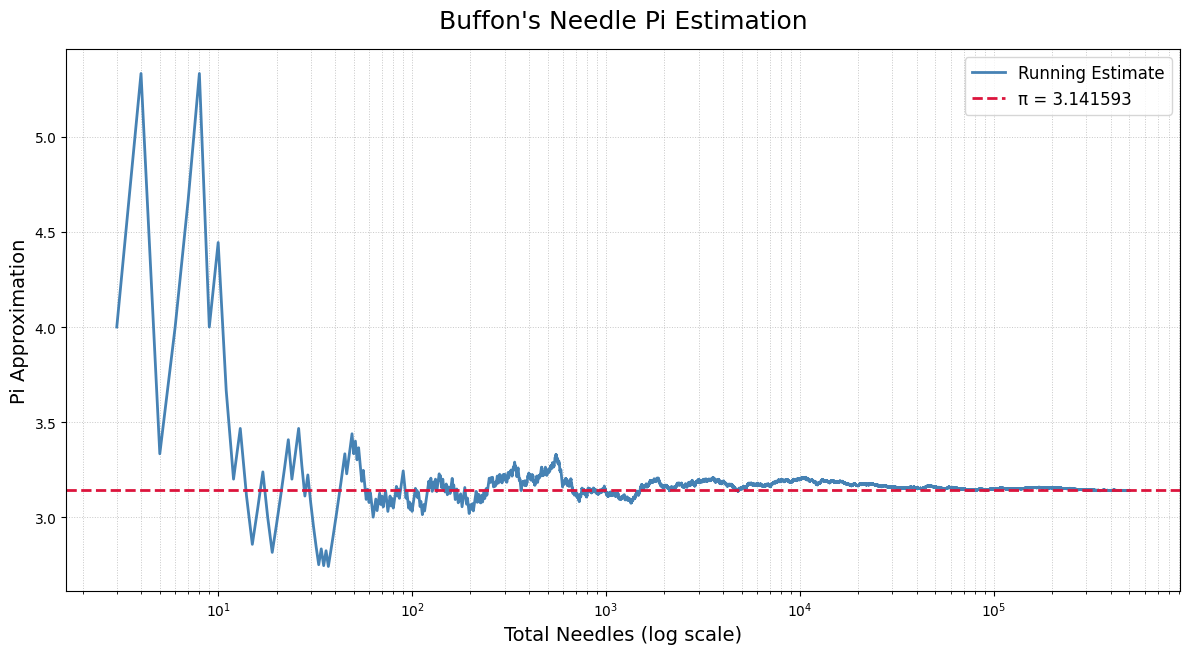

In [31]:
needle_indices = np.arange(1, TOTAL_NEEDLES + 1)

plt.figure(figsize=(12, 7))
plt.plot(needle_indices, running_pi, linewidth=2, color="steelblue", label="Running Estimate")
plt.axhline(y=np.pi, color="crimson", linestyle="--", linewidth=2, label=f"π = {np.pi:.6f}")
plt.xscale("log")
plt.xlabel("Total Needles (log scale)", fontsize=14)
plt.ylabel("Pi Approximation", fontsize=14)
plt.title("Buffon's Needle Pi Estimation", fontsize=18, pad=15)
plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()